<a href="https://colab.research.google.com/github/zeeshan3106/Machine-Learning/blob/main/Decision%20Tree%20Classifiert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import pandas as pd
data = pd.read_csv("nadal_matches_100.csv")
X = data.drop("Nadal_Won", axis=1)
y = data["Nadal_Won"]
data.head(2)


,Opponent_Tier,Court_Surface,Nadal_Injury_Status,Opponent_Hand,Match_Importance,Nadal_Won
0,Elite,Clay,Healthy,Right,Grand_Slam,Yes
1,Elite,Clay,Healthy,Right,Grand_Slam,Yes


In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=True)

In [29]:
from sklearn.preprocessing import OrdinalEncoder
ord = OrdinalEncoder()
X_train_transform = ord.fit_transform(X_train)
X_test_trans = ord.transform(X_test)
X_train_transform = pd.DataFrame(X_train_transform, columns=X_train.columns)
X_test_trans = pd.DataFrame(X_test_trans, columns=X_test.columns)



In [48]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth = 4)
training = tree.fit(X_train_transform, y_train)
pred = tree.predict(X_test_trans)
pred

array(['Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
       'No'], dtype=object)

In [89]:
def function (Opponent_Tier,Court_Surface,Nadal_Injury_Status,Opponent_Hand,Match_Importance):
  aray = [Opponent_Tier,Court_Surface,Nadal_Injury_Status,Opponent_Hand,Match_Importance]
  aray_transform = ord.transform([aray])
  predict = tree.predict(aray_transform)
  return predict




Opponent_Tier="Elite"
Court_Surface="Clay"
Nadal_Injury_Status="Healthy"
Opponent_Hand="Right"
Match_Importance="Grand_Slam"




prediction = function(Opponent_Tier,Court_Surface,Nadal_Injury_Status,Opponent_Hand,Match_Importance)
if(prediction == "Yes"):
  predictions = "Nadal Won"
else:
  predictions = "Nadal Lost"
pd.DataFrame([predictions, prediction])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,0
0,Nadal Won
1,[Yes]


In [50]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred )*100

95.0

In [54]:
import numpy as np
import pandas as pd
from sklearn.tree import export_text

print("--- DECISION TREE RULES LOGIC ---")
tree_rules = export_text(tree, feature_names=list(X_train_transform.columns))
print(tree_rules)
print("\n--- FEATURE IMPORTANCE RANKING ---")
importances = tree.feature_importances_
feature_names = X_train_transform.columns
indices = np.argsort(importances)[::-1]

for rank, i in enumerate(indices):
    print(f"{rank + 1}. {feature_names[i]}: {importances[i]*100:.2f}% impact")

--- DECISION TREE RULES LOGIC ---
|--- Court_Surface <= 0.50
|   |--- Nadal_Injury_Status <= 1.50
|   |   |--- class: Yes
|   |--- Nadal_Injury_Status >  1.50
|   |   |--- Opponent_Tier <= 0.50
|   |   |   |--- class: Yes
|   |   |--- Opponent_Tier >  0.50
|   |   |   |--- class: No
|--- Court_Surface >  0.50
|   |--- Nadal_Injury_Status <= 0.50
|   |   |--- Opponent_Tier <= 0.50
|   |   |   |--- class: Yes
|   |   |--- Opponent_Tier >  0.50
|   |   |   |--- Opponent_Tier <= 1.50
|   |   |   |   |--- class: No
|   |   |   |--- Opponent_Tier >  1.50
|   |   |   |   |--- class: Yes
|   |--- Nadal_Injury_Status >  0.50
|   |   |--- Opponent_Tier <= 0.50
|   |   |   |--- Court_Surface <= 1.50
|   |   |   |   |--- class: No
|   |   |   |--- Court_Surface >  1.50
|   |   |   |   |--- class: Yes
|   |   |--- Opponent_Tier >  0.50
|   |   |   |--- class: No


--- FEATURE IMPORTANCE RANKING ---
1. Nadal_Injury_Status: 39.50% impact
2. Court_Surface: 31.91% impact
3. Opponent_Tier: 28.59% impact

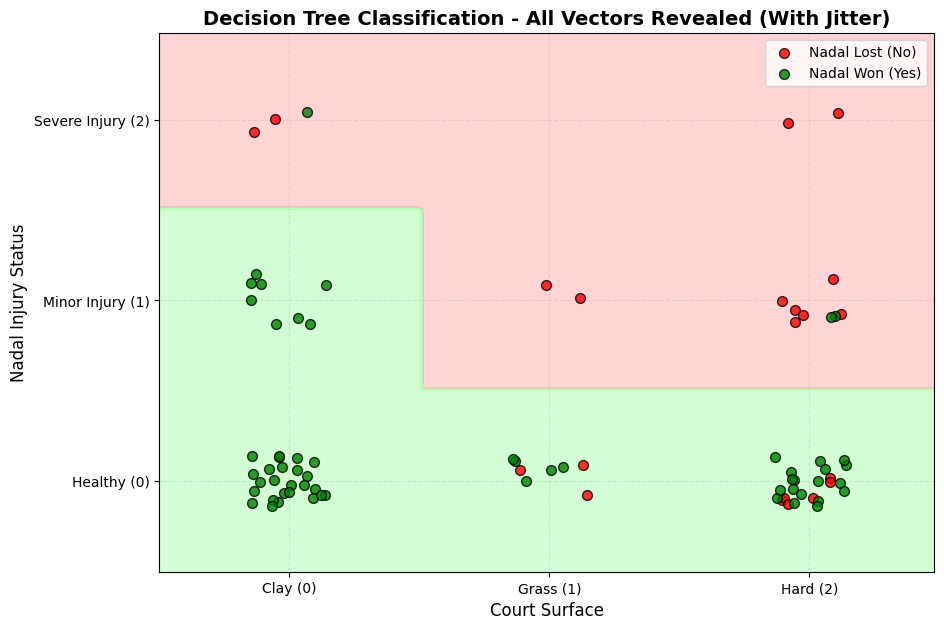

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier

X_visual = X_train_transform[['Court_Surface', 'Nadal_Injury_Status']].values
y_visual = y_train.map({'No': 0, 'Yes': 1}).values

clf_2d = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_2d.fit(X_visual, y_visual)
x_min, x_max = X_visual[:, 0].min() - 0.5, X_visual[:, 0].max() + 0.5
y_min, y_max = X_visual[:, 1].min() - 0.5, X_visual[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_background = ListedColormap(['#FFAAAA', '#AAFFAA'])  # Light Red (No), Light Green (Yes)
cmap_points = ['red', 'green']                            # Dark Red (No), Dark Green (Yes)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_background)
np.random.seed(42)
X_jittered = X_visual + np.random.uniform(-0.15, 0.15, size=X_visual.shape)

for class_value, color, label in zip([0, 1], cmap_points, ['Nadal Lost (No)', 'Nadal Won (Yes)']):
    mask = (y_visual == class_value)
    plt.scatter(X_jittered[mask, 0],
                X_jittered[mask, 1],
                c=color, label=label, edgecolor='k', s=50, alpha=0.8, zorder=3)

plt.xticks(ticks=[0, 1, 2], labels=['Clay (0)', 'Grass (1)', 'Hard (2)'])
plt.yticks(ticks=[0, 1, 2], labels=['Healthy (0)', 'Minor Injury (1)', 'Severe Injury (2)'])

plt.title("Decision Tree Classification - All Vectors Revealed (With Jitter)", fontsize=14, fontweight='bold')
plt.xlabel("Court Surface", fontsize=12)
plt.ylabel("Nadal Injury Status", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [91]:
def function (Opponent_Tier,Court_Surface,Nadal_Injury_Status,Opponent_Hand,Match_Importance):
  aray = [Opponent_Tier,Court_Surface,Nadal_Injury_Status,Opponent_Hand,Match_Importance]
  aray_transform = ord.transform([aray])
  predict = tree.predict(aray_transform)
  return predict




Opponent_Tier="Elite"
Court_Surface="Clay"
Nadal_Injury_Status="Healthy"
Opponent_Hand="Right"
Match_Importance="Grand_Slam"




prediction = function(Opponent_Tier,Court_Surface,Nadal_Injury_Status,Opponent_Hand,Match_Importance)
if(prediction == "Yes"):
  predictions = "Nadal Won"
else:
  predictions = "Nadal Lost"
pd.DataFrame([predictions, prediction])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,0
0,Nadal Won
1,[Yes]
